# Cognifyz Machine Learning Internship

## Task 4 — Location-Based Analysis

### Objective

Perform a geographical analysis of the restaurants in the dataset.

### Analysis Areas

- Restaurant distribution using latitude and longitude
- Restaurant concentration by city
- Restaurant concentration by locality
- Average restaurant ratings by location
- Price range patterns by location
- Cuisine distribution by location
- Geographical patterns and insights

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [49]:
df = pd.read_csv(
    "../outputs/results/location_clean_restaurants.csv"
)

print(df.shape)

(9054, 21)


In [50]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [51]:
print("Latitude range:")
print(df["Latitude"].min(), "to", df["Latitude"].max())

print("\nLongitude range:")
print(df["Longitude"].min(), "to", df["Longitude"].max())

Latitude range:
-41.330428 to 55.97698

Longitude range:
-157.948486 to 174.8320893


In [52]:
print(
    "Missing Latitude:",
    df["Latitude"].isnull().sum()
)

print(
    "Missing Longitude:",
    df["Longitude"].isnull().sum()
)

Missing Latitude: 0
Missing Longitude: 0


In [53]:
fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    hover_name="Restaurant Name",
    hover_data=[
        "City",
        "Locality",
        "Aggregate rating",
        "Price range"
    ],
    title="Geographical Distribution of Restaurants"
)

fig.show()

In [54]:
fig.write_html(
    "../outputs/figures/task4_restaurant_distribution_map.html"
)

In [55]:
fig = px.scatter_geo(
    df,
    lat="Latitude",
    lon="Longitude",
    color="Aggregate rating",
    size="Votes",
    hover_name="Restaurant Name",
    hover_data=[
        "City",
        "Locality",
        "Cuisines",
        "Price range"
    ],
    title="Restaurant Locations by Rating and Popularity"
)

fig.show()

In [56]:
city_counts = (
    df["City"]
    .value_counts()
)

city_counts.head(15)

City
New Delhi                 5240
Gurgaon                   1070
Noida                      987
Faridabad                  229
Ghaziabad                   25
Ahmedabad                   21
Bras�_lia                   20
Rio de Janeiro              20
S��o Paulo                  20
Albany                      20
Athens                      20
Augusta                     20
Boise                       20
Cedar Rapids/Iowa City      20
Columbus                    20
Name: count, dtype: int64

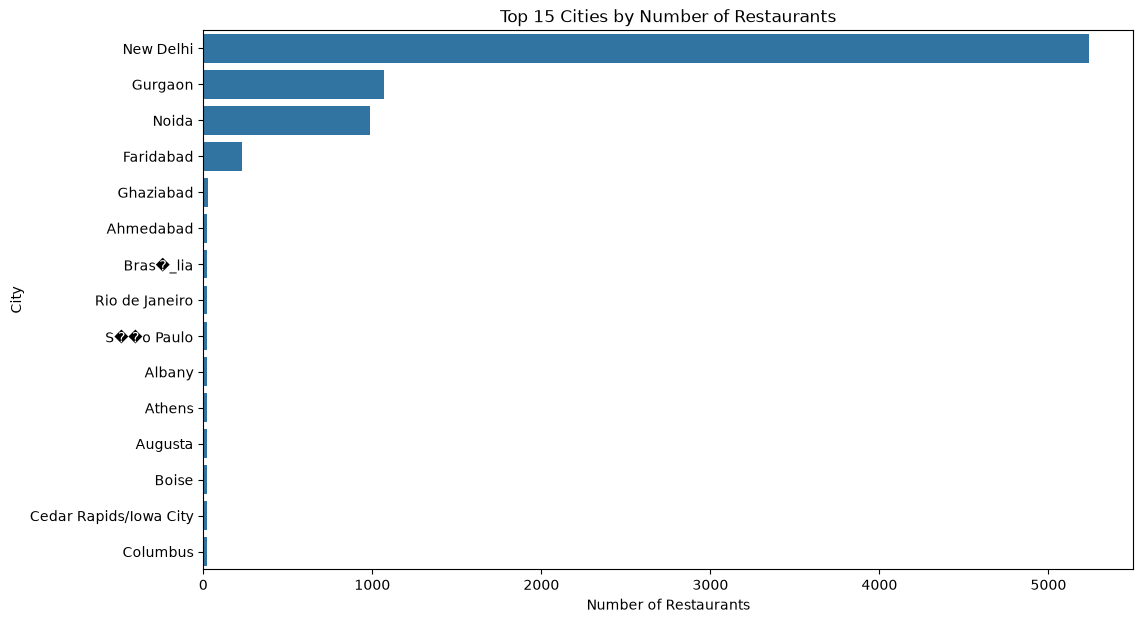

In [57]:
top_cities = city_counts.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.savefig(
    "../outputs/figures/task4_top_cities.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [58]:
city_percentage = (
    city_counts /
    city_counts.sum() * 100
)

city_summary = pd.DataFrame({
    "Restaurant Count": city_counts,
    "Percentage": city_percentage.round(2)
})

city_summary.head(15)

,Restaurant Count,Percentage
City,,
New Delhi,5240,57.87
Gurgaon,1070,11.82
Noida,987,10.90
Faridabad,229,2.53
Ghaziabad,25,0.28
Ahmedabad,21,0.23
Bras�_lia,20,0.22
Rio de Janeiro,20,0.22
S��o Paulo,20,0.22


In [59]:
city_summary.to_csv(
    "../outputs/results/task4_city_restaurant_distribution.csv"
)

In [60]:
locality_counts = (
    df["Locality"]
    .value_counts()
)

locality_counts.head(20)

Locality
Connaught Place           122
Rajouri Garden             98
Malviya Nagar              85
Defence Colony             85
Pitampura                  83
Shahdara                   81
Rajinder Nagar             79
Karol Bagh                 75
Satyaniketan               75
Sector 18                  75
Mayur Vihar Phase 1        73
Hauz Khas                  71
Kalkaji                    71
Safdarjung                 70
Sector 62                  70
DLF Phase 3                68
Krishna Nagar              67
Sector 15                  66
Greater Kailash (GK) 2     66
Mahipalpur                 66
Name: count, dtype: int64

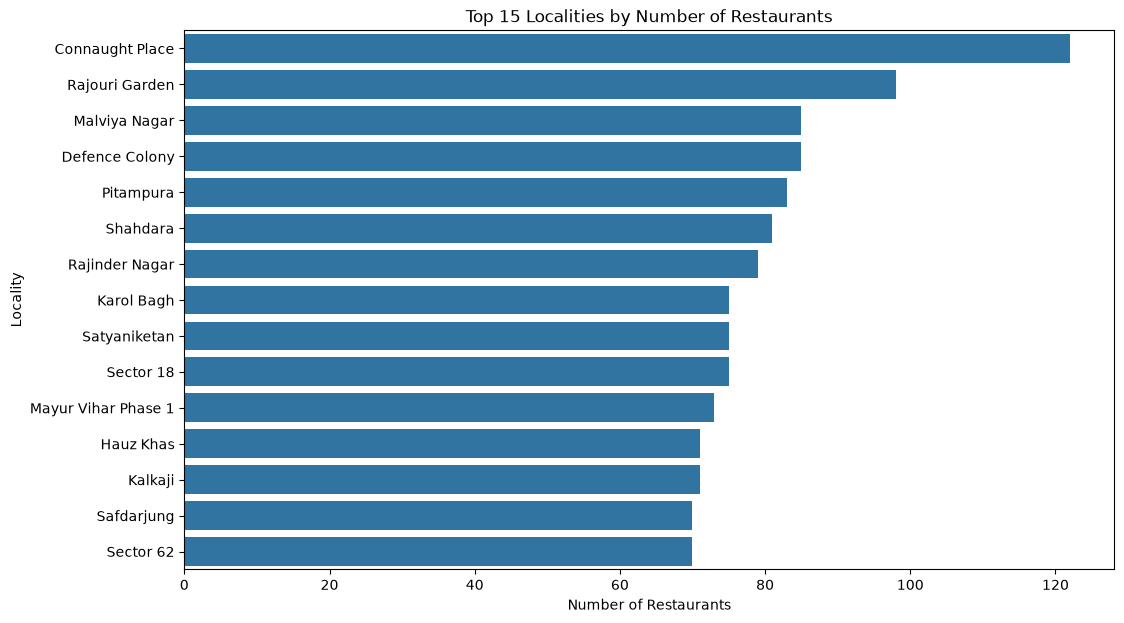

In [61]:
top_localities = locality_counts.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_localities.values,
    y=top_localities.index
)

plt.title("Top 15 Localities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Locality")

plt.savefig(
    "../outputs/figures/task4_top_localities.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [62]:
locality_summary = pd.DataFrame({
    "Restaurant Count": locality_counts,
    "Percentage": (
        locality_counts /
        locality_counts.sum() * 100
    ).round(2)
})

locality_summary.to_csv(
    "../outputs/results/task4_locality_distribution.csv"
)

In [63]:
rated_df = df[
    df["Aggregate rating"] > 0
].copy()

In [64]:
city_rating = (
    rated_df
    .groupby("City")["Aggregate rating"]
    .agg(
        Average_Rating="mean",
        Rated_Restaurants="count"
    )
    .sort_values(
        "Average_Rating",
        ascending=False
    )
)

city_rating.head(15)

,Average_Rating,Rated_Restaurants
City,,
Inner City,4.900000,2
Quezon City,4.800000,1
Makati City,4.650000,2
Pasig City,4.633333,3
Mandaluyong City,4.625000,4
Beechworth,4.600000,1
London,4.535000,20
Taguig City,4.525000,4
Secunderabad,4.500000,2


In [65]:
city_rating_reliable = city_rating[
    city_rating["Rated_Restaurants"] >= 10
].copy()

In [66]:
city_rating_reliable.head(15)

,Average_Rating,Rated_Restaurants
City,,
London,4.535000,20
Rio de Janeiro,4.489474,19
Orlando,4.475000,20
Jakarta,4.420000,15
Rest of Hawaii,4.410000,20
Tampa Bay,4.410000,20
Bangalore,4.375000,20
Dubai,4.370000,20
Hyderabad,4.344444,18


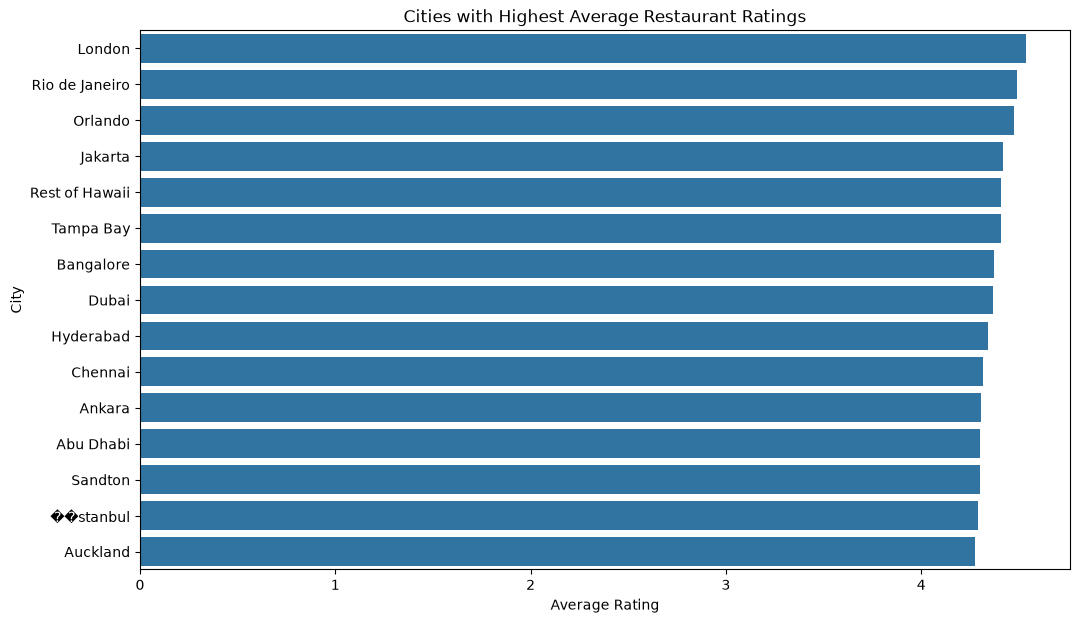

In [67]:
top_rating_cities = (
    city_rating_reliable
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_rating_cities["Average_Rating"],
    y=top_rating_cities.index
)

plt.title(
    "Cities with Highest Average Restaurant Ratings"
)
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.savefig(
    "../outputs/figures/task4_average_rating_by_city.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [68]:
city_price = (
    df
    .groupby("City")["Price range"]
    .agg(
        Average_Price_Range="mean",
        Restaurant_Count="count"
    )
    .sort_values(
        "Average_Price_Range",
        ascending=False
    )
)

city_price.head(15)

,Average_Price_Range,Restaurant_Count
City,,
Panchkula,4.000000,1
Vineland Station,4.000000,1
Paynesville,4.000000,1
Johannesburg,4.000000,6
Inner City,4.000000,2
Pasay City,4.000000,3
Princeton,4.000000,1
Sandton,3.818182,11
Mandaluyong City,3.750000,4


In [69]:
city_price_reliable = city_price[
    city_price["Restaurant_Count"] >= 10
]

city_price_reliable.head(15)

,Average_Price_Range,Restaurant_Count
City,,
Sandton,3.818182,11
Pretoria,3.700000,20
Singapore,3.650000,20
Doha,3.650000,20
Goa,3.647059,17
S��o Paulo,3.600000,20
Rio de Janeiro,3.500000,20
Sharjah,3.300000,20
Abu Dhabi,3.300000,20


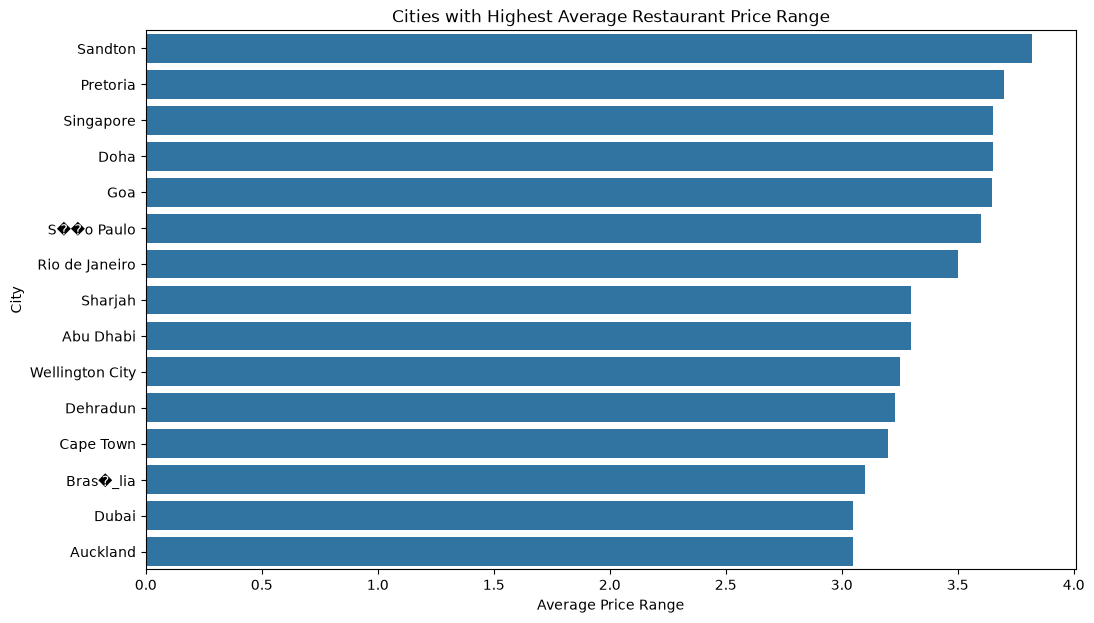

In [70]:
top_expensive_cities = (
    city_price_reliable
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_expensive_cities["Average_Price_Range"],
    y=top_expensive_cities.index
)

plt.title(
    "Cities with Highest Average Restaurant Price Range"
)

plt.xlabel("Average Price Range")
plt.ylabel("City")

plt.savefig(
    "../outputs/figures/task4_average_price_range_by_city.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [71]:
city_cuisine = (
    df.groupby(
        ["City", "Cuisines"]
    )
    .size()
    .reset_index(
        name="Restaurant Count"
    )
)

In [72]:
city_cuisine.head(20)

,City,Cuisines,Restaurant Count
0,Abu Dhabi,American,2
1,Abu Dhabi,"American, Desserts",1
2,Abu Dhabi,"American, Mexican, Seafood",1
3,Abu Dhabi,Asian,1
4,Abu Dhabi,Chinese,1
5,Abu Dhabi,"Fast Food, Burger",1
6,Abu Dhabi,"Filipino, Japanese, Asian",1
7,Abu Dhabi,Indian,2
8,Abu Dhabi,"Indian, North Indian",1
9,Abu Dhabi,"Indian, North Indian, Chinese",1


In [73]:
top_city_cuisines = (
    city_cuisine
    .sort_values(
        ["City", "Restaurant Count"],
        ascending=[True, False]
    )
    .groupby("City")
    .head(1)
)

top_city_cuisines.head(20)

,City,Cuisines,Restaurant Count
0,Abu Dhabi,American,2
25,Agra,"North Indian, Mughlai",4
28,Ahmedabad,"Cafe, American, Continental, Armenian, Fast Food",1
65,Albany,Unknown,3
73,Allahabad,"North Indian, Chinese",2
81,Amritsar,North Indian,7
94,Ankara,"Kebab, Turkish Pizza",4
102,Armidale,"Bar Food, Steak",1
105,Athens,"American, Italian, Pizza",2
126,Auckland,Cafe,2


In [74]:
major_cities = (
    df["City"]
    .value_counts()
    .head(10)
    .index
)

major_city_cuisines = city_cuisine[
    city_cuisine["City"].isin(major_cities)
]

In [75]:
major_city_cuisines = (
    major_city_cuisines
    .sort_values(
        ["City", "Restaurant Count"],
        ascending=[True, False]
    )
    .groupby("City")
    .head(5)
)

major_city_cuisines

,City,Cuisines,Restaurant Count
28,Ahmedabad,"Cafe, American, Continental, Armenian, Fast Food",1
29,Ahmedabad,"Cafe, Beverages, Desserts, Pizza",1
30,Ahmedabad,"Cafe, Continental, Desserts",1
31,Ahmedabad,"Cafe, Italian",1
32,Ahmedabad,"Chinese, Italian, North Indian, Mexican, Medit...",1
65,Albany,Unknown,3
60,Albany,"Japanese, Steak, Sushi",2
49,Albany,"American, BBQ",1
50,Albany,"American, Breakfast, Diner",1
51,Albany,"American, Burger, Sandwich",1


In [76]:
city_price_distribution = pd.crosstab(
    df["City"],
    df["Price range"]
)

city_price_distribution.head()

Price range,1,2,3,4
City,,,,
Abu Dhabi,0,4,6,10
Agra,2,5,4,3
Ahmedabad,1,8,11,1
Albany,11,5,3,1
Allahabad,2,3,9,1


In [77]:
top_10_cities = (
    df["City"]
    .value_counts()
    .head(10)
    .index
)

top_city_price_distribution = (
    city_price_distribution
    .loc[top_10_cities]
)

top_city_price_distribution

Price range,1,2,3,4
City,,,,
New Delhi,2894,1591,542,213
Gurgaon,419,426,158,67
Noida,499,376,92,20
Faridabad,134,81,14,0
Ghaziabad,9,13,2,1
Ahmedabad,1,8,11,1
Bras�_lia,2,4,4,10
Rio de Janeiro,0,1,8,11
S��o Paulo,0,2,4,14


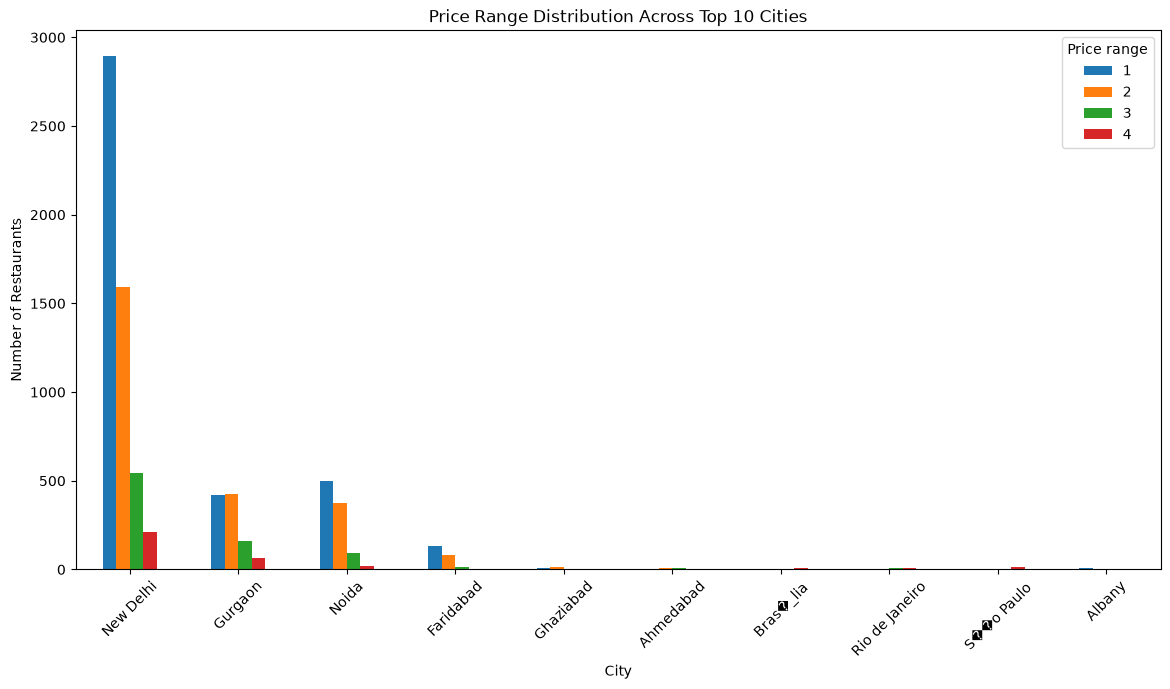

In [78]:
top_city_price_distribution.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Price Range Distribution Across Top 10 Cities"
)

plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.savefig(
    "../outputs/figures/task4_price_distribution_top_cities.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [79]:
locality_rating = (
    rated_df
    .groupby("Locality")["Aggregate rating"]
    .agg(
        Average_Rating="mean",
        Rated_Restaurants="count"
    )
    .sort_values(
        "Average_Rating",
        ascending=False
    )
)

In [80]:
locality_rating_reliable = locality_rating[
    locality_rating["Rated_Restaurants"] >= 10
]

In [81]:
locality_rating_reliable.head(15)

,Average_Rating,Rated_Restaurants
Locality,,
Macon,4.310000,10
Te Aro,4.300000,15
Boise,4.266667,18
Athens,4.200000,20
Pensacola,4.200000,12
Savannah,4.188889,18
Augusta,4.140000,15
Davenport,4.092308,13
Columbus,4.010526,19


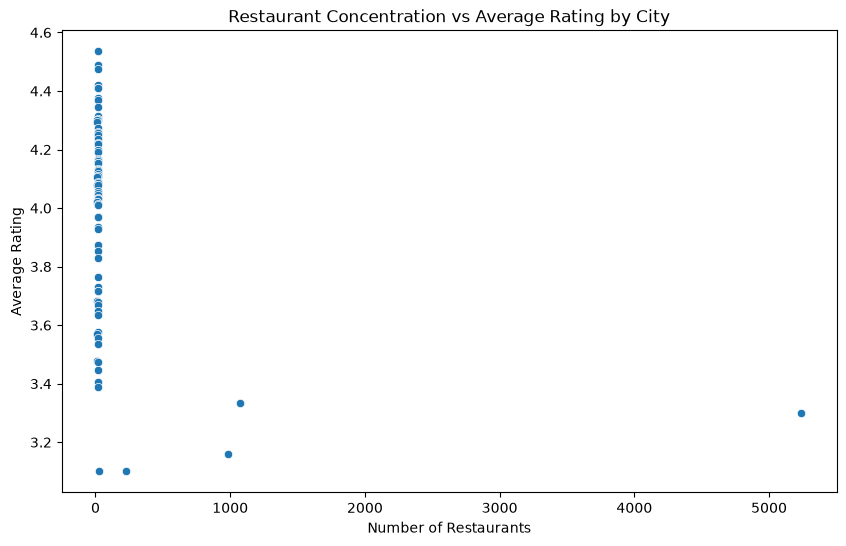

In [82]:
city_analysis = city_rating_reliable.join(
    city_summary,
    how="inner"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=city_analysis,
    x="Restaurant Count",
    y="Average_Rating"
)

plt.title(
    "Restaurant Concentration vs Average Rating by City"
)

plt.xlabel("Number of Restaurants")
plt.ylabel("Average Rating")

plt.savefig(
    "../outputs/figures/task4_restaurant_count_vs_rating.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [83]:
city_coordinates = (
    df.groupby("City")
    .agg(
        Latitude=("Latitude", "mean"),
        Longitude=("Longitude", "mean"),
        Restaurant_Count=("Restaurant ID", "count"),
        Average_Rating=("Aggregate rating", "mean")
    )
    .reset_index()
)

In [84]:
fig = px.scatter_geo(
    city_coordinates,
    lat="Latitude",
    lon="Longitude",
    size="Restaurant_Count",
    color="Average_Rating",
    hover_name="City",
    hover_data=[
        "Restaurant_Count",
        "Average_Rating"
    ],
    title="Restaurant Concentration and Average Rating by City"
)

fig.show()

In [85]:
fig.write_html(
    "../outputs/figures/task4_city_level_map.html"
)

In [86]:
city_statistics = (
    df.groupby("City")
    .agg(
        Restaurant_Count=("Restaurant ID", "count"),
        Average_Price_Range=("Price range", "mean"),
        Average_Rating=("Aggregate rating", "mean")
    )
)

In [87]:
rated_city_statistics = (
    rated_df.groupby("City")
    .agg(
        Average_Rated_Rating=(
            "Aggregate rating",
            "mean"
        ),
        Rated_Restaurants=(
            "Restaurant ID",
            "count"
        )
    )
)

In [88]:
city_statistics = city_statistics.join(
    rated_city_statistics,
    how="left"
)

city_statistics.head()

,Restaurant_Count,Average_Price_Range,Average_Rating,Average_Rated_Rating,Rated_Restaurants
City,,,,,
Abu Dhabi,20,3.300000,4.300000,4.300000,20
Agra,14,2.571429,4.021429,4.021429,14
Ahmedabad,21,2.571429,4.161905,4.161905,21
Albany,20,1.700000,3.555000,3.555000,20
Allahabad,15,2.600000,3.406667,3.406667,15


In [89]:
city_statistics.to_csv(
    "../outputs/results/task4_city_statistics.csv"
)

In [90]:
top_city_summary = (
    city_statistics
    .sort_values(
        "Restaurant_Count",
        ascending=False
    )
    .head(15)
)

top_city_summary

,Restaurant_Count,Average_Price_Range,Average_Rating,Average_Rated_Rating,Rated_Restaurants
City,,,,,
New Delhi,5240,1.632443,2.502061,3.298314,3975
Gurgaon,1070,1.881308,2.721963,3.332380,874
Noida,987,1.628166,2.166261,3.158198,677
Faridabad,229,1.475983,1.991703,3.102721,147
Ghaziabad,25,1.800000,2.852000,3.100000,23
Ahmedabad,21,2.571429,4.161905,4.161905,21
Augusta,20,2.150000,4.130000,4.130000,20
Cedar Rapids/Iowa City,20,2.050000,4.165000,4.165000,20
Auckland,20,3.050000,4.275000,4.275000,20


In [91]:
top_city_summary.to_csv(
    "../outputs/results/task4_top_city_summary.csv"
)

In [92]:
largest_city = (
    city_statistics
    .sort_values(
        "Restaurant_Count",
        ascending=False
    )
    .head(1)
)

highest_rated_city = (
    city_statistics[
        city_statistics["Rated_Restaurants"] >= 10
    ]
    .sort_values(
        "Average_Rated_Rating",
        ascending=False
    )
    .head(1)
)

highest_price_city = (
    city_statistics[
        city_statistics["Restaurant_Count"] >= 10
    ]
    .sort_values(
        "Average_Price_Range",
        ascending=False
    )
    .head(1)
)

print("Largest city by restaurant count:")
display(largest_city)

print("\nHighest-rated city among cities with at least 10 rated restaurants:")
display(highest_rated_city)

print("\nHighest average price range among cities with at least 10 restaurants:")
display(highest_price_city)

Largest city by restaurant count:


,Restaurant_Count,Average_Price_Range,Average_Rating,Average_Rated_Rating,Rated_Restaurants
City,,,,,
New Delhi,5240,1.632443,2.502061,3.298314,3975



Highest-rated city among cities with at least 10 rated restaurants:


,Restaurant_Count,Average_Price_Range,Average_Rating,Average_Rated_Rating,Rated_Restaurants
City,,,,,
London,20,3.0,4.535,4.535,20



Highest average price range among cities with at least 10 restaurants:


,Restaurant_Count,Average_Price_Range,Average_Rating,Average_Rated_Rating,Rated_Restaurants
City,,,,,
Sandton,11,3.818182,4.3,4.3,11


# Day 13 — Task 4 Progress

## Work Completed

- Loaded the location-clean restaurant dataset.
- Verified latitude and longitude values.
- Visualized the geographical distribution of restaurants.
- Analyzed restaurant concentration by city.
- Analyzed restaurant concentration by locality.
- Calculated restaurant counts and percentages by city.
- Calculated average ratings by city using rated restaurants.
- Calculated average price range by city.
- Analyzed cuisine distributions across cities.
- Analyzed price-range distributions across major cities.
- Analyzed rating patterns by locality.
- Created interactive geographical visualizations.
- Generated city-level summary statistics.

## Important Analysis Considerations

Restaurants with Aggregate rating = 0 were treated as "Not rated"
when calculating meaningful average rating statistics.

Cities or localities with very small numbers of restaurants were
excluded from comparative rankings where appropriate to reduce
misleading conclusions.

The geographical analysis is descriptive and does not establish
causal relationships.

# Task 4 — Key Insights

## Restaurant Concentration

[Write the actual result obtained from the dataset.]

## Rating Patterns

[Write the actual highest/lowest reliable city or locality result.]

## Price Patterns

[Write the actual price range patterns observed.]

## Cuisine Patterns

[Write the most common cuisine patterns observed by location.]

## Geographical Patterns

[Write observations from the interactive maps.]

## Limitations

The analysis is based on the restaurants represented in the
provided dataset and therefore may not represent the complete
restaurant market of every city.

Average rating comparisons can be affected by the number of rated
restaurants in each location.

Latitude and longitude records with invalid zero coordinates were
excluded from geographical analysis.

The analysis identifies associations and patterns but does not
establish causation.